In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"E:\vs\Loan Default Prediction\dataset\loan_train.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df["loan_status"].value_counts())

(27003, 47)
        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0   540179     697401      10000        10000           9975.0   36 months   
1   585434     752191      14000        14000          13775.0   36 months   
2   457736     569298       9475         9475           9475.0   36 months   
3   734349     930860       4000         4000           4000.0   36 months   
4  1050080    1281522       3600         3600           3600.0   36 months   

  int_rate  installment grade sub_grade  ... total_pymnt_inv total_rec_prncp  \
0   13.23%       338.05     C        C1  ...        11943.68        10000.00   
1    7.88%       437.94     A        A5  ...        15470.79        14000.00   
2    8.94%       301.04     A        A5  ...        10472.09         9475.00   
3    7.29%       124.04     A        A4  ...         4425.26         4000.00   
4    6.62%       110.54     A        A2  ...         2321.34         2004.17   

  total_rec_int  total_rec_late_fee re

In [38]:
print(df.columns.tolist())
print(df["loan_status"].value_counts())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'pub_rec_bankruptcies']
loan_status
0    23026
1     3977
Name: count, dtype: int64


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27003 entries, 0 to 27002
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       27003 non-null  int64  
 1   member_id                27003 non-null  int64  
 2   loan_amnt                27003 non-null  int64  
 3   funded_amnt              27003 non-null  int64  
 4   funded_amnt_inv          27003 non-null  float64
 5   term                     27003 non-null  str    
 6   int_rate                 27003 non-null  str    
 7   installment              27003 non-null  float64
 8   grade                    27003 non-null  str    
 9   sub_grade                27003 non-null  str    
 10  emp_title                25321 non-null  str    
 11  emp_length               26273 non-null  str    
 12  home_ownership           27003 non-null  str    
 13  annual_inc               27003 non-null  float64
 14  verification_status      27003 no

In [40]:
drop_columns = [
    # Identifiers
    "id",
    "member_id",
    "url",

    # Free-text columns
    "emp_title",
    "desc",
    "title",

    # Location identifiers
    "zip_code",
    "addr_state",

    # Post-loan / target leakage
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
    "funded_amnt",
    "funded_amnt_inv",
    "grade"

]

df_model = df.drop(columns=drop_columns)

print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Shape: (27003, 24)
['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'pub_rec_bankruptcies']


In [41]:
rename_columns = {
    "loan_amnt": "Loan Amount",
    "term": "Loan Term",
    "int_rate": "Interest Rate",
    "installment": "Monthly Installment",
    "sub_grade": "Loan Sub Grade",
    "emp_length": "Employment Length",
    "home_ownership": "Home Ownership",
    "annual_inc": "Annual Income",
    "verification_status": "Income Verification",
    "issue_d": "Issue Date",
    "purpose": "Loan Purpose",
    "dti": "Debt To Income Ratio",
    "delinq_2yrs": "Delinquencies Last 2 Years",
    "earliest_cr_line": "Earliest Credit Line",
    "inq_last_6mths": "Credit Inquiries Last 6 Months",
    "mths_since_last_delinq": "Months Since Last Delinquency",
    "mths_since_last_record": "Months Since Last Public Record",
    "open_acc": "Open Credit Accounts",
    "pub_rec": "Public Records",
    "revol_bal": "Revolving Balance",
    "revol_util": "Revolving Utilization",
    "total_acc": "Total Credit Accounts",
    "pub_rec_bankruptcies": "Public Record Bankruptcies",
    "loan_status": "Loan Default"
}

df_model = df_model.rename(columns=rename_columns)

print(df_model.columns.tolist())

['Loan Amount', 'Loan Term', 'Interest Rate', 'Monthly Installment', 'Loan Sub Grade', 'Employment Length', 'Home Ownership', 'Annual Income', 'Income Verification', 'Issue Date', 'Loan Default', 'Loan Purpose', 'Debt To Income Ratio', 'Delinquencies Last 2 Years', 'Earliest Credit Line', 'Credit Inquiries Last 6 Months', 'Months Since Last Delinquency', 'Months Since Last Public Record', 'Open Credit Accounts', 'Public Records', 'Revolving Balance', 'Revolving Utilization', 'Total Credit Accounts', 'Public Record Bankruptcies']


In [42]:
df_model["Interest Rate"] = (
    df_model["Interest Rate"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

print(df_model["Interest Rate"].head())
print(df_model["Interest Rate"].dtype)

0    13.23
1     7.88
2     8.94
3     7.29
4     6.62
Name: Interest Rate, dtype: float64
float64


In [43]:
df_model["Revolving Utilization"] = (
    df_model["Revolving Utilization"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

print(df_model["Revolving Utilization"].head())
print(df_model["Revolving Utilization"].dtype)

0    62.7
1    28.8
2    44.7
3    69.1
4    70.1
Name: Revolving Utilization, dtype: float64
float64


In [44]:
df_model["Loan Term"] = (
    df_model["Loan Term"]
    .str.replace(" months", "", regex=False)
    .astype(int)
)

print(df_model["Loan Term"].value_counts())

Loan Term
36    20382
60     6621
Name: count, dtype: int64


In [45]:
df_model["Employment Length"] = (
    df_model["Employment Length"]
    .str.replace("< 1 year", "0", regex=False)
    .str.replace("10+ years", "10", regex=False)
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
)

df_model["Employment Length"] = pd.to_numeric(
    df_model["Employment Length"],
    errors="coerce"
)

print(df_model["Employment Length"].value_counts().sort_index())

Employment Length
0.0     3133
1.0     2185
2.0     2987
3.0     2819
4.0     2325
5.0     2249
6.0     1494
7.0     1165
8.0     1030
9.0      870
10.0    6016
Name: count, dtype: int64


In [46]:
df_model["Issue Date"] = pd.to_datetime(
    df_model["Issue Date"],
    format="%b-%y"
)

print(df_model["Issue Date"].head())
print(df_model["Issue Date"].dtype)

0   2010-07-01
1   2010-09-01
2   2009-11-01
3   2011-04-01
4   2011-12-01
Name: Issue Date, dtype: datetime64[us]
datetime64[us]


In [47]:
df_model["Issue Year"] = df_model["Issue Date"].dt.year
df_model["Issue Month"] = df_model["Issue Date"].dt.month

print(df_model[["Issue Date", "Issue Year", "Issue Month"]].head())

  Issue Date  Issue Year  Issue Month
0 2010-07-01        2010            7
1 2010-09-01        2010            9
2 2009-11-01        2009           11
3 2011-04-01        2011            4
4 2011-12-01        2011           12


In [48]:
df_model["Earliest Credit Line"] = pd.to_datetime(
    df_model["Earliest Credit Line"],
    format="%b-%y"
)

print(df_model[["Earliest Credit Line"]].head())
print(df_model["Earliest Credit Line"].dtype)

  Earliest Credit Line
0           2002-09-01
1           2005-07-01
2           1999-05-01
3           1997-12-01
4           1999-04-01
datetime64[us]


In [49]:
df_model["Credit History Years"] = (
    df_model["Issue Date"] - df_model["Earliest Credit Line"]
).dt.days / 365.25

print(df_model[[
    "Issue Date",
    "Earliest Credit Line",
    "Credit History Years"
]].head())

  Issue Date Earliest Credit Line  Credit History Years
0 2010-07-01           2002-09-01              7.830253
1 2010-09-01           2005-07-01              5.169062
2 2009-11-01           1999-05-01             10.505133
3 2011-04-01           1997-12-01             13.330595
4 2011-12-01           1999-04-01             12.668036


In [50]:
df_model = df_model.drop(
    columns=["Issue Date", "Earliest Credit Line"]
)

print(df_model.columns)
print(df_model.shape)

Index(['Loan Amount', 'Loan Term', 'Interest Rate', 'Monthly Installment',
       'Loan Sub Grade', 'Employment Length', 'Home Ownership',
       'Annual Income', 'Income Verification', 'Loan Default', 'Loan Purpose',
       'Debt To Income Ratio', 'Delinquencies Last 2 Years',
       'Credit Inquiries Last 6 Months', 'Months Since Last Delinquency',
       'Months Since Last Public Record', 'Open Credit Accounts',
       'Public Records', 'Revolving Balance', 'Revolving Utilization',
       'Total Credit Accounts', 'Public Record Bankruptcies', 'Issue Year',
       'Issue Month', 'Credit History Years'],
      dtype='str')
(27003, 25)


In [51]:
missing = df_model.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Months Since Last Public Record    25065
Months Since Last Delinquency      17395
Employment Length                    730
Public Record Bankruptcies           503
Revolving Utilization                 35
dtype: int64


In [52]:
df_model = df_model.drop(
    columns=[
        "Months Since Last Public Record",
        "Months Since Last Delinquency"
    ]
)

print(df_model.shape)

(27003, 23)


In [53]:
df_model["Employment Length"] = df_model["Employment Length"].fillna(
    df_model["Employment Length"].median()
)

df_model["Public Record Bankruptcies"] = df_model["Public Record Bankruptcies"].fillna(
    df_model["Public Record Bankruptcies"].median()
)

df_model["Revolving Utilization"] = df_model["Revolving Utilization"].fillna(
    df_model["Revolving Utilization"].median()
)

In [54]:
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Series([], dtype: int64)


In [55]:
print(df_model.dtypes)

Loan Amount                         int64
Loan Term                           int64
Interest Rate                     float64
Monthly Installment               float64
Loan Sub Grade                        str
Employment Length                 float64
Home Ownership                        str
Annual Income                     float64
Income Verification                   str
Loan Default                        int64
Loan Purpose                          str
Debt To Income Ratio              float64
Delinquencies Last 2 Years          int64
Credit Inquiries Last 6 Months      int64
Open Credit Accounts                int64
Public Records                      int64
Revolving Balance                   int64
Revolving Utilization             float64
Total Credit Accounts               int64
Public Record Bankruptcies        float64
Issue Year                          int32
Issue Month                         int32
Credit History Years              float64
dtype: object


In [56]:
X = df_model.drop("Loan Default", axis=1)
y = df_model["Loan Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (27003, 22)
y shape: (27003,)
Loan Default
0    23026
1     3977
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (16201, 22)
Validation: (5401, 22)
Testing: (5401, 22)


In [58]:
print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Loan Default
0    13815
1     2386
Name: count, dtype: int64

Validation:
Loan Default
0    4605
1     796
Name: count, dtype: int64

Testing:
Loan Default
0    4606
1     795
Name: count, dtype: int64


In [66]:
train_data = X_train.copy()
train_data["Loan Default"] = y_train

df_default = train_data[train_data["Loan Default"] == 1]
df_non_default = train_data[train_data["Loan Default"] == 0]

df_non_default_sample = df_non_default.sample(
    n=len(df_default),
    random_state=42
)

df_train_balanced = pd.concat(
    [df_default, df_non_default_sample]
)

df_train_balanced = df_train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df_train_balanced["Loan Default"].value_counts())

Loan Default
1    2386
0    2386
Name: count, dtype: int64


In [67]:
X_train_balanced = df_train_balanced.drop(
    "Loan Default",
    axis=1
)

y_train_balanced = df_train_balanced["Loan Default"]

print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)

X_train_balanced: (4772, 22)
y_train_balanced: (4772,)


In [68]:
categorical_features = X_train_balanced.select_dtypes(
    include=["str", "object"]
).columns.tolist()

numerical_features = X_train_balanced.select_dtypes(
    exclude=["str", "object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Loan Sub Grade', 'Home Ownership', 'Income Verification', 'Loan Purpose']

Numerical features:
['Loan Amount', 'Loan Term', 'Interest Rate', 'Monthly Installment', 'Employment Length', 'Annual Income', 'Debt To Income Ratio', 'Delinquencies Last 2 Years', 'Credit Inquiries Last 6 Months', 'Open Credit Accounts', 'Public Records', 'Revolving Balance', 'Revolving Utilization', 'Total Credit Accounts', 'Public Record Bankruptcies', 'Issue Year', 'Issue Month', 'Credit History Years']


In [69]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [70]:
X_train_processed = preprocessor.fit_transform(X_train_balanced)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [71]:
print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Testing:", X_test_processed.shape)


Training: (4772, 74)
Validation: (5401, 74)
Testing: (5401, 74)


In [72]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(sigmoid(-5))
print(sigmoid(0))
print(sigmoid(5))

0.0066928509242848554
0.5
0.9933071490757153


In [73]:
n_features = X_train_processed.shape[1]

weights = np.zeros(n_features)
bias = 0

print("Number of weights:", len(weights))
print("Bias:", bias)

Number of weights: 74
Bias: 0


In [75]:
z = X_train_processed @ weights + bias

print("z shape:", z.shape)
print("First 5 z values:", z[:5])

z shape: (4772,)
First 5 z values: [0. 0. 0. 0. 0.]


In [76]:
probabilities = sigmoid(z)

print("First 5 probabilities:", probabilities[:5])

First 5 probabilities: [0.5 0.5 0.5 0.5 0.5]


In [77]:
def log_loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [78]:
loss = log_loss(
    y_train_balanced.to_numpy(),
    probabilities
)

print("Initial Log Loss:", loss)

Initial Log Loss: 0.6931471805599452


In [79]:
y_train_array = y_train_balanced.to_numpy()

error = probabilities - y_train_array

dw = (X_train_processed.T @ error) / len(y_train_array)
db = np.mean(error)

print("Gradient shape:", dw.shape)
print("Bias gradient:", db)
print("First 5 weight gradients:", dw[:5])

Gradient shape: (74,)
Bias gradient: 0.0
First 5 weight gradients: [-0.04025306 -0.11040237 -0.14283706 -0.02186068 -0.0019819 ]


In [80]:
learning_rate = 0.01

weights = weights - learning_rate * dw
bias = bias - learning_rate * db

print("First 5 updated weights:", weights[:5])
print("Updated bias:", bias)


First 5 updated weights: [4.02530625e-04 1.10402372e-03 1.42837056e-03 2.18606834e-04
 1.98190499e-05]
Updated bias: 0.0


In [81]:
def train_logistic_regression(X, y, learning_rate=0.01, iterations=2000):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0.0
    
    loss_history = []
    
    for i in range(iterations):
        
        # Forward pass
        z = X @ weights + bias
        probabilities = sigmoid(z)
        
        # Loss
        loss = log_loss(y, probabilities)
        loss_history.append(loss)
        
        # Gradient
        error = probabilities - y
        
        dw = (X.T @ error) / n_samples
        db = np.mean(error)
        
        # Update
        weights -= learning_rate * dw
        bias -= learning_rate * db
    
    return weights, bias, loss_history

In [82]:
y_train_array = y_train_balanced.to_numpy()

weights, bias, loss_history = train_logistic_regression(
    X_train_processed,
    y_train_array,
    learning_rate=0.01,
    iterations=2000
)

print("Final bias:", bias)
print("First 5 weights:", weights[:5])
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

Final bias: 0.018613994660523974
First 5 weights: [0.03539761 0.29248893 0.39178555 0.00205538 0.01535275]
Initial loss: 0.6931471805599452
Final loss: 0.6286584205532715


In [83]:
def predict_probability(X, weights, bias):
    z = X @ weights + bias
    return sigmoid(z)


def predict(X, weights, bias, threshold=0.5):
    probabilities = predict_probability(X, weights, bias)
    return (probabilities >= threshold).astype(int)

In [84]:
y_train_prob = predict_probability(
    X_train_processed, weights, bias
)

y_val_prob = predict_probability(
    X_val_processed, weights, bias
)

y_test_prob = predict_probability(
    X_test_processed, weights, bias
)

y_train_pred = predict(
    X_train_processed, weights, bias
)

y_val_pred = predict(
    X_val_processed, weights, bias
)

y_test_pred = predict(
    X_test_processed, weights, bias
)

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

def evaluate_model(y_true, y_pred, y_prob):
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
    print("Log Loss :", log_loss(y_true, y_prob))

In [86]:
print("===== TRAINING =====")

evaluate_model(
    y_train_balanced,
    y_train_pred,
    y_train_prob
)

===== TRAINING =====
Accuracy : 0.6508801341156748
Precision: 0.6533219761499148
Recall   : 0.6429170159262364
F1 Score : 0.648077735530207
ROC-AUC  : 0.7020259631308365
Log Loss : 0.6286566061219041


In [87]:
print("\n===== VALIDATION =====")

evaluate_model(
    y_val,
    y_val_pred,
    y_val_prob
)


===== VALIDATION =====
Accuracy : 0.6491390483243844
Precision: 0.24067956583294006
Recall   : 0.6407035175879398
F1 Score : 0.34991423670668953
ROC-AUC  : 0.710815205233551
Log Loss : 0.6269873999747403


In [88]:
print("\n===== TESTING =====")

evaluate_model(
    y_test,
    y_test_pred,
    y_test_prob
)



===== TESTING =====
Accuracy : 0.6506202555082392
Precision: 0.23875598086124403
Recall   : 0.6276729559748427
F1 Score : 0.3459272097053726
ROC-AUC  : 0.7018248005745854
Log Loss : 0.6250172731240163


[[3015 1591]
 [ 296  499]]


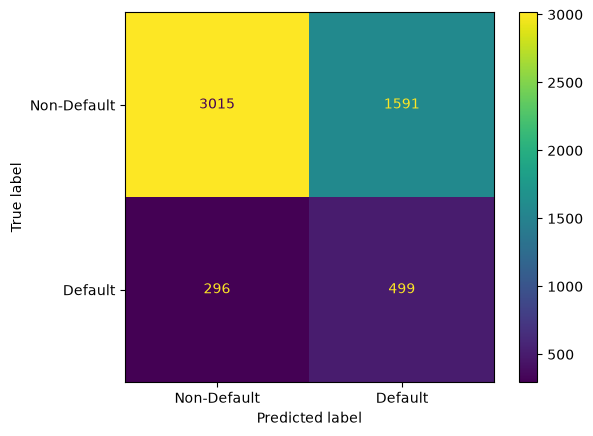

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

disp.plot()
plt.show()

In [91]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred_threshold),
        "Recall": recall_score(y_val, y_val_pred_threshold),
        "F1 Score": f1_score(y_val, y_val_pred_threshold)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df.round(3))

    Threshold  Precision  Recall  F1 Score
0        0.10      0.147   0.996     0.257
1        0.15      0.148   0.996     0.258
2        0.20      0.152   0.994     0.264
3        0.25      0.162   0.984     0.278
4        0.30      0.176   0.961     0.298
5        0.35      0.189   0.913     0.314
6        0.40      0.206   0.843     0.331
7        0.45      0.225   0.763     0.347
8        0.50      0.241   0.641     0.350
9        0.55      0.262   0.523     0.349
10       0.60      0.297   0.411     0.345
11       0.65      0.322   0.310     0.316
12       0.70      0.345   0.216     0.266
13       0.75      0.380   0.132     0.196
14       0.80      0.477   0.052     0.093
15       0.85      0.500   0.006     0.012
16       0.90      0.000   0.000     0.000


c:\Users\ads2609025\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [92]:
best_threshold = threshold_df.loc[
    threshold_df["F1 Score"].idxmax(),
    "Threshold"
]

print("Selected threshold:", best_threshold)

Selected threshold: 0.5000000000000001


In [93]:
y_test_pred_tuned = (
    y_test_prob >= best_threshold
).astype(int)

print("Test Results After Threshold Tuning")

print("Accuracy :", accuracy_score(y_test, y_test_pred_tuned))
print("Precision:", precision_score(y_test, y_test_pred_tuned))
print("Recall   :", recall_score(y_test, y_test_pred_tuned))
print("F1 Score :", f1_score(y_test, y_test_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))
print("Log Loss :", log_loss(y_test, y_test_prob))


Test Results After Threshold Tuning
Accuracy : 0.6506202555082392
Precision: 0.23875598086124403
Recall   : 0.6276729559748427
F1 Score : 0.3459272097053726
ROC-AUC  : 0.7018248005745854
Log Loss : 0.6250172731240163


[[3015 1591]
 [ 296  499]]


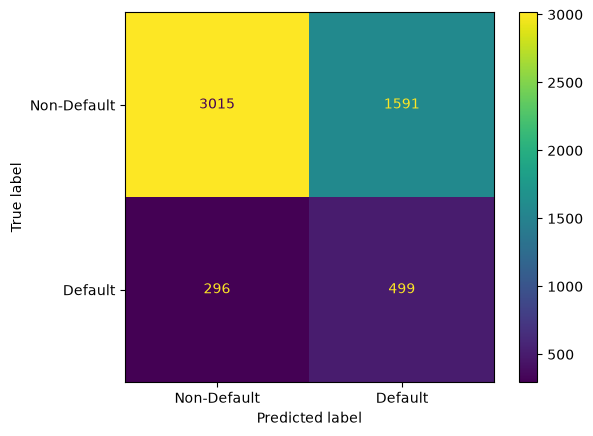

In [94]:
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print(cm_tuned)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Non-Default", "Default"]
).plot()

plt.show()


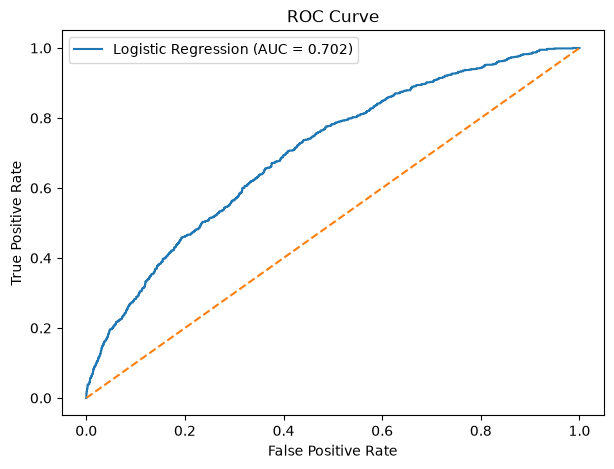

In [95]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_prob)

auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

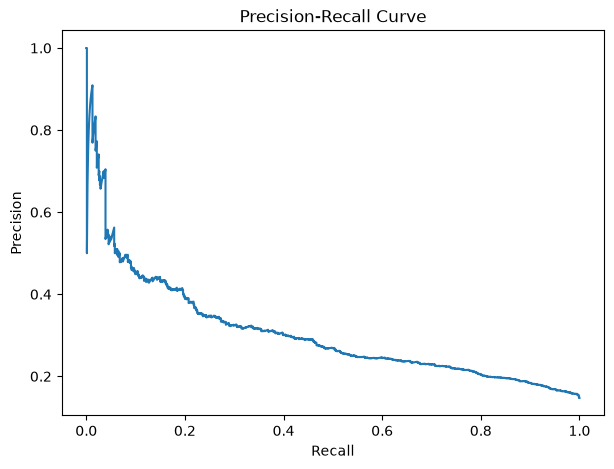

In [96]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [97]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

sklearn_model.fit(
    X_train_processed,
    y_train_array
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [98]:
y_train_prob_sklearn = sklearn_model.predict_proba(
    X_train_processed
)[:, 1]

y_val_prob_sklearn = sklearn_model.predict_proba(
    X_val_processed
)[:, 1]

y_test_prob_sklearn = sklearn_model.predict_proba(
    X_test_processed
)[:, 1]


In [99]:
y_test_pred_sklearn = (
    y_test_prob_sklearn >= 0.5
).astype(int)

In [100]:
print("SKLEARN LOGISTIC REGRESSION")

evaluate_model(
    y_test,
    y_test_pred_sklearn,
    y_test_prob_sklearn
)

SKLEARN LOGISTIC REGRESSION
Accuracy : 0.6506202555082392
Precision: 0.24342105263157895
Recall   : 0.6515723270440251
F1 Score : 0.35443037974683544
ROC-AUC  : 0.7013657329652054
Log Loss : 0.6276411629900202


In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Log Loss"
    ],
    "From Scratch": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob),
        log_loss(y_test, y_test_prob)
    ],
    "Sklearn": [
        accuracy_score(y_test, y_test_pred_sklearn),
        precision_score(y_test, y_test_pred_sklearn),
        recall_score(y_test, y_test_pred_sklearn),
        f1_score(y_test, y_test_pred_sklearn),
        roc_auc_score(y_test, y_test_prob_sklearn),
        log_loss(y_test, y_test_prob_sklearn)
    ]
})

print(comparison.round(4))

      Metric  From Scratch  Sklearn
0   Accuracy        0.6506   0.6506
1  Precision        0.2388   0.2434
2     Recall        0.6277   0.6516
3   F1 Score        0.3459   0.3544
4    ROC-AUC        0.7018   0.7014
5   Log Loss        0.6250   0.6276


In [102]:
feature_names = preprocessor.get_feature_names_out()

coefficients = sklearn_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute Coefficient",
    ascending=False
)

print(feature_importance.head(20))

                             Feature  Coefficient  Absolute Coefficient
71  cat__Loan Purpose_small_business     0.745851              0.745851
52            cat__Loan Sub Grade_G5     0.731427              0.731427
45            cat__Loan Sub Grade_F3    -0.485638              0.485638
18            cat__Loan Sub Grade_A1    -0.485258              0.485258
43            cat__Loan Sub Grade_F1    -0.456672              0.456672
50            cat__Loan Sub Grade_G3     0.449583              0.449583
54         cat__Home Ownership_OTHER     0.442725              0.442725
2                 num__Interest Rate     0.436336              0.436336
44            cat__Loan Sub Grade_F2    -0.430364              0.430364
61     cat__Loan Purpose_credit_card    -0.397860              0.397860
60             cat__Loan Purpose_car    -0.365302              0.365302
5                 num__Annual Income    -0.356119              0.356119
51            cat__Loan Sub Grade_G4     0.351664              0

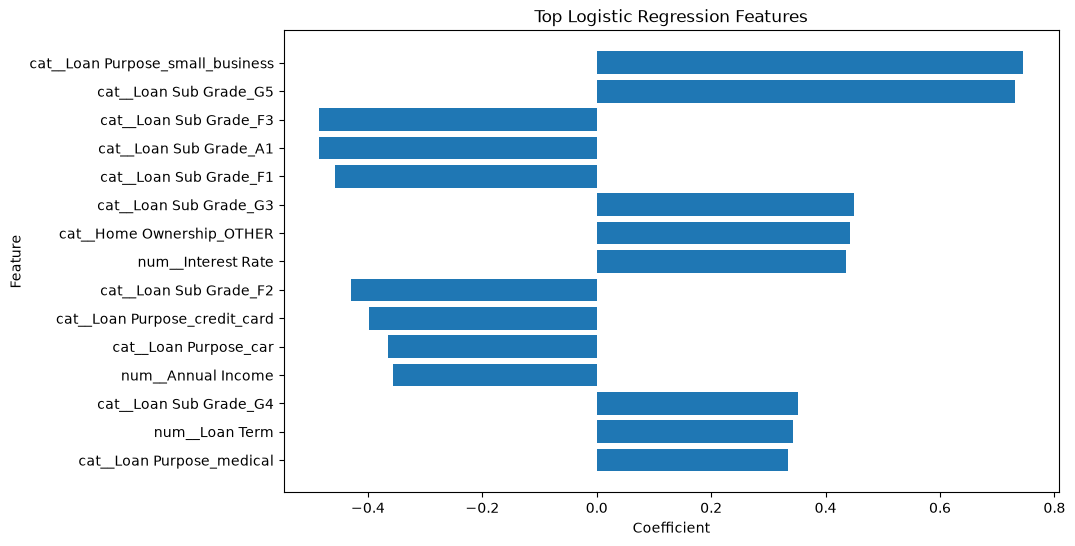

In [103]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Features")
plt.gca().invert_yaxis()

plt.show()

In [104]:
feature_importance["Odds Ratio"] = np.exp(
    feature_importance["Coefficient"]
)

print(
    feature_importance[
        ["Feature", "Coefficient", "Odds Ratio"]
    ].head(20)
)

                             Feature  Coefficient  Odds Ratio
71  cat__Loan Purpose_small_business     0.745851    2.108235
52            cat__Loan Sub Grade_G5     0.731427    2.078044
45            cat__Loan Sub Grade_F3    -0.485638    0.615305
18            cat__Loan Sub Grade_A1    -0.485258    0.615539
43            cat__Loan Sub Grade_F1    -0.456672    0.633388
50            cat__Loan Sub Grade_G3     0.449583    1.567658
54         cat__Home Ownership_OTHER     0.442725    1.556945
2                 num__Interest Rate     0.436336    1.547028
44            cat__Loan Sub Grade_F2    -0.430364    0.650273
61     cat__Loan Purpose_credit_card    -0.397860    0.671756
60             cat__Loan Purpose_car    -0.365302    0.693987
5                 num__Annual Income    -0.356119    0.700389
51            cat__Loan Sub Grade_G4     0.351664    1.421431
1                     num__Loan Term     0.342739    1.408801
67         cat__Loan Purpose_medical     0.334202    1.396826
69      

[[3015 1591]
 [ 296  499]]


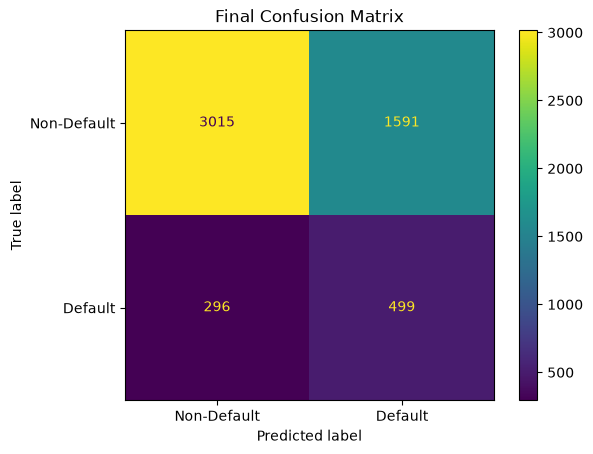

In [105]:
cm = confusion_matrix(
    y_test,
    y_test_pred_tuned
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("Final Confusion Matrix")
plt.show()

In [106]:
import joblib

joblib.dump(
    sklearn_model,
    "loan_logistic_model.pkl"
)

joblib.dump(
    preprocessor,
    "loan_preprocessor.pkl"
)

joblib.dump(
    best_threshold,
    "loan_threshold.pkl"
)

['loan_threshold.pkl']